In [ ]:
!git clone https://github.com/weathon/vsf.git
!cd vsf && git stash && git switch fix_flux

fatal: destination path 'vsf' already exists and is not an empty directory.
No local changes to save
Already on 'fix_flux'
Your branch is up to date with 'origin/fix_flux'.


In [ ]:
!pip install compel

In [ ]:
!pip install hpsv2

In [ ]:
import sys
import torch
sys.path.append("vsf")

import torch
import sys
from diffusers import FluxTransformer2DModel
from pathlib import Path

# from diffusers import FluxPipeline
from src.flux_pipeline import VSFFluxPipeline

dance_pipe = VSFFluxPipeline.from_pretrained(
    "weathon/dance_flux",
    # "black-forest-labs/FLUX.1-dev",
    torch_dtype=torch.bfloat16,
)
dance_pipe = dance_pipe.to("cuda:0")


README.md:   0%|          | 0.00/442 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/66.3k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/300 [00:00<?, ? examples/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

You set `add_prefix_space`. The tokenizer needs to be converted from the slow tokenizers
`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

In [ ]:
images_aa = dance_pipe(
    prompt="A mother holding a baby sitting in front of a ruin during a war. Houses behind them are broken. The mother shows a facial expression of hopeless",
    negative_prompt="Hopeful, joyful, safe, intact, thriving, clean",
    scale=4.5,
    offset=0
).images

torch.Size([1, 1, 4096]) torch.Size([1, 14, 4096])
torch.Size([1, 498, 4096]) torch.Size([498, 3]) torch.Size([1, 14, 4096]) torch.Size([14, 3])
processor counts 19 38


  0%|          | 0/28 [00:00<?, ?it/s]

In [ ]:
images_original = dance_pipe(
    prompt="A mother holding a baby sitting in front of a ruin during a war. Houses behind them are broken. The mother shows a facial expression of hopeless hopeless hopeless hopeless hopeless hopeless hopeless hopeless hopeless hopeless hopeless hopeless hopeless hopeless hopeless hopeless hopeless hopeless hopeless hopeless hopeless hopeless hopeless hopeless hopeless hopeless hopeless hopeless hopeless hopeless hopeless hopeless hopeless hopeless hopeless hopeless hopeless hopeless hopeless hopeless hopeless hopeless hopeless hopeless hopeless hopeless hopeless hopeless hopeless hopeless",
    negative_prompt="",
    scale=4.5,
    offset=0
).images

Token indices sequence length is longer than the specified maximum sequence length for this model (80 > 77). Running this sequence through the model will result in indexing errors
The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['hopeless hopeless hopeless']


torch.Size([1, 1, 4096]) torch.Size([1, 1, 4096])
torch.Size([1, 511, 4096]) torch.Size([511, 3]) torch.Size([1, 1, 4096]) torch.Size([1, 3])
processor counts 19 38


  0%|          | 0/28 [00:00<?, ?it/s]

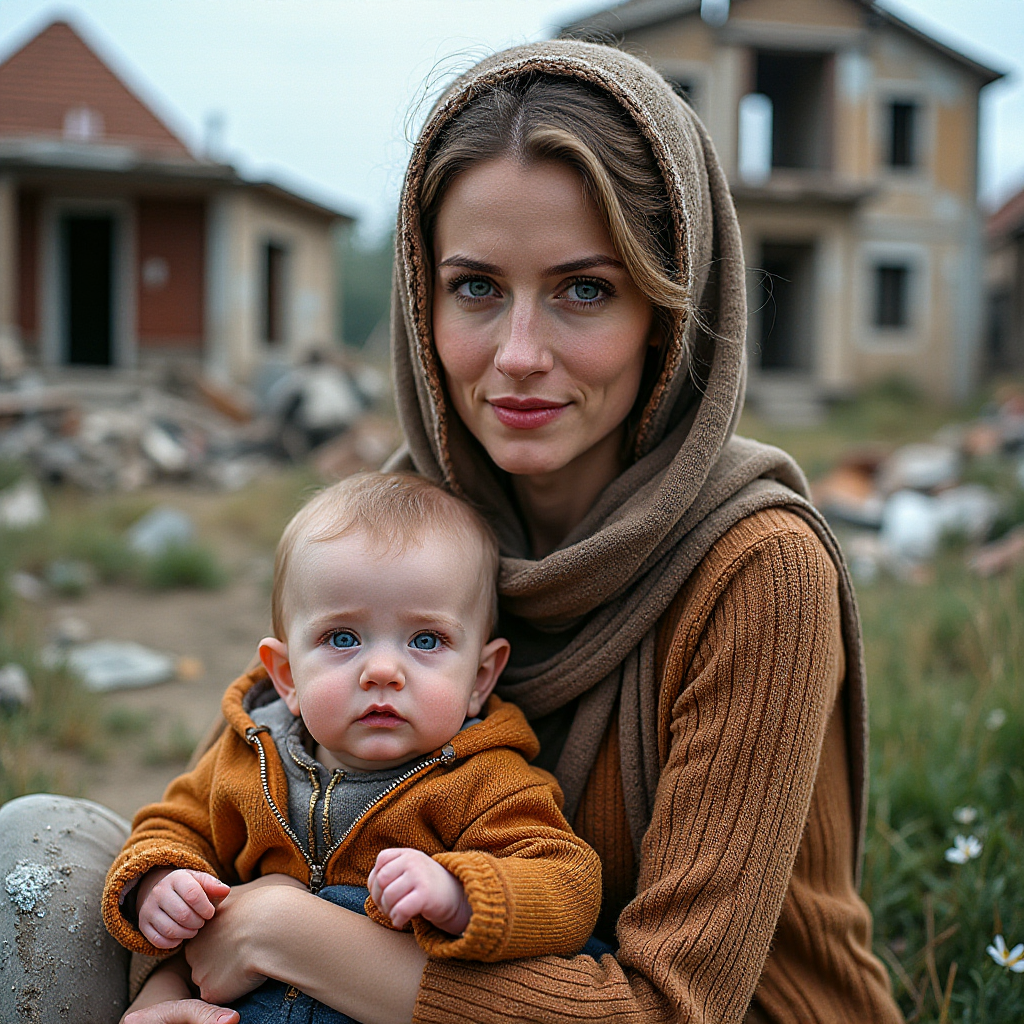

In [ ]:
images_original[0]

In [ ]:
import hpsv2

# imgs_path can be a list of image paths, with the images generated by the same prompt
# or image path of string type
# or image of PIL.Image.Image type
result = hpsv2.score(imgs_path, '<prompt>', hps_version="v2.1")

NameError: name 'imgs_path' is not defined